<a href="https://colab.research.google.com/github/Alamgir-JUST/ASTRID-Net/blob/main/ASTRID_Net_for_Multiclass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [ ]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/IIoT/DNN-EdgeIIoT-dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/IIoT/DNN-EdgeIIoT-dataset.csv'

In [ ]:
df.shape

(2219201, 63)

In [ ]:
df

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2219196,2021 23:24:32.816050000,166.75.162.225,192.168.0.128,0,0.0,0.0,0,31814.0,45620.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP
2219197,2021 23:24:32.816595000,70.162.34.183,192.168.0.128,0,0.0,0.0,0,27718.0,45636.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP
2219198,2021 23:24:32.818043000,40.13.95.244,192.168.0.128,0,0.0,0.0,0,18502.0,45672.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP
2219199,2021 23:24:32.820831000,18.132.75.125,192.168.0.128,0,0.0,0.0,0,1862.0,45737.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP


In [ ]:
df['Attack_type'].value_counts()

,count
Attack_type,
Normal,1615643
DDoS_UDP,121568
DDoS_ICMP,116436
SQL_injection,51203
Password,50153
Vulnerability_scanner,50110
DDoS_TCP,50062
DDoS_HTTP,49911
Uploading,37634


# **Data Preprocessing**

In [ ]:
df

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2219196,2021 23:24:32.816050000,166.75.162.225,192.168.0.128,0,0.0,0.0,0,31814.0,45620.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP
2219197,2021 23:24:32.816595000,70.162.34.183,192.168.0.128,0,0.0,0.0,0,27718.0,45636.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP
2219198,2021 23:24:32.818043000,40.13.95.244,192.168.0.128,0,0.0,0.0,0,18502.0,45672.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP
2219199,2021 23:24:32.820831000,18.132.75.125,192.168.0.128,0,0.0,0.0,0,1862.0,45737.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP


## **Handle Missing Values**

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Only show columns with missing values

print("Columns with Missing Values:\n", missing_values)


Columns with Missing Values:
 Series([], dtype: int64)


In [ ]:

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values in numerical columns with median
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Fill missing values in categorical columns with mode
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

# Verify if missing values are filled
print("Missing values after filling:\n", df.isnull().sum().sum())  # Should be 0 if all missing values are handled


Missing values after filling:
 0


In [ ]:
df.shape

(2219201, 63)

In [ ]:
# Remove unnecessary columns that are not useful for attack prediction
columns_to_drop = ['Attack_label']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')  # errors='ignore' avoids error if column is missing

print("Remaining columns after dropping:", df.shape[1])


Remaining columns after dropping: 62


In [ ]:
# Print the names of the features (columns)
print(df.columns)

Index(['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
       'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum',
       'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused',
       'http.file_data', 'http.content_length', 'http.request.uri.query',
       'http.request.method', 'http.referer', 'http.request.full_uri',
       'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack',
       'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin',
       'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack',
       'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options',
       'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream',
       'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu',
       'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request',
       'dns.retransmit_request_in', 'mqtt.conack.flags',
       'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Preprocessing steps
# Replace infinity and large values with NaNs
#df = df.replace([np.inf, -np.inf], np.nan)
#df = df.replace(to_replace=[r'^(-?\d+\.\d+e\+\d+|-?\d+\.\d+e-\d+|-?\d+\.\d+|-?\d+)$', r'^(-?\d+)$'], value=np.nan, regex=True)

# Drop rows containing NaNs
#df.dropna(inplace=True)

# Separate numerical and categorical columns, excluding the 'Label' column from categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.difference(['Attack_type'])

# Normalize numerical columns
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Ensure all categorical values are strings
df[cat_cols] = df[cat_cols].astype(str)

# Encode categorical columns
encoder = LabelEncoder()
df[cat_cols] = df[cat_cols].apply(encoder.fit_transform)

# Display the processed DataFrame
df

In [ ]:
X = df.drop(columns=['Attack_type'])
y = df['Attack_type']

In [ ]:
df.shape

In [ ]:
df['Attack_type'].value_counts()

In [ ]:
df

In [ ]:
!pip install tensorflow

# **Proposed ASTRID-Net Model**

In [ ]:
# Imports
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization, Conv1D,
    GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate,
    Bidirectional, GRU, Multiply, Permute, Add, Activation, Reshape
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# --- Attention and building blocks ---

def squeeze_excitation_block(input_tensor, ratio=16):
    channels = input_tensor.shape[-1]
    se = GlobalAveragePooling1D()(input_tensor)
    se = Dense(channels // ratio, activation='relu')(se)
    se = Dense(channels, activation='sigmoid')(se)
    se = Reshape((1, channels))(se)
    return Multiply()([input_tensor, se])

def spatial_attention_block(input_tensor):
    avg_pool = tf.reduce_mean(input_tensor, axis=-1, keepdims=True)
    max_pool = tf.reduce_max(input_tensor, axis=-1, keepdims=True)
    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    spatial_att = Conv1D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    return Multiply()([input_tensor, spatial_att])

def residual_multi_scale_conv_block(input_tensor, filters=64, kernel_sizes=[3,5,7]):
    convs = [Conv1D(filters, k, padding='same', activation='relu')(input_tensor) for k in kernel_sizes]
    concat = Concatenate()(convs)
    norm = LayerNormalization()(concat)
    if input_tensor.shape[-1] != norm.shape[-1]:
        input_proj = Conv1D(norm.shape[-1], kernel_size=1, padding='same')(input_tensor)
    else:
        input_proj = input_tensor
    out = Add()([norm, input_proj])
    return Activation('relu')(out)

def temporal_attention(input_seq):
    permuted = Permute((2, 1))(input_seq)
    attention = Dense(input_seq.shape[1], activation='softmax')(permuted)
    attention = Permute((2, 1))(attention)
    return Multiply()([input_seq, attention])

# --- Model Definition ---

def ASTRID_Net(input_shape, num_classes, dropout_rate=0.3):
    inputs = Input(shape=input_shape)
    x = residual_multi_scale_conv_block(inputs)
    x = Bidirectional(GRU(64, return_sequences=True))(x)
    x = LayerNormalization()(x)
    x = temporal_attention(x)
    x = squeeze_excitation_block(x)
    x = spatial_attention_block(x)
    x = GlobalMaxPooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs, name="CST_AFNet_v2")
    return model

# === STEP 1: Prepare Dataset ===

# Assuming your DataFrame df exists and 'Attack_type' is the target
X = df.drop(columns=['Attack_type']).values.astype(np.float32)
y = df['Attack_type'].values

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Feature scaling (StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for Conv1D input: (samples, time_steps, channels=1)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# === STEP 2: Build & Compile CST-AFNet v2 ===
input_shape = X_train.shape[1:]  # (features, 1)
model = ASTRID_Net(input_shape, num_classes)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# === 🛠️ STEP 3: Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_cst_afnet_v2_model.h5", save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

callbacks = [early_stop, checkpoint, reduce_lr]

# === STEP 4: Training ===
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 60, 1)     │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 60, 64)    │        256 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 60, 64)    │        384 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 60, 64)    │        512 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 60, 192)   │          0 │ conv1d_3[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_4[0][0],   │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 192)   │        768 │ concatenate_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 60, 192)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 60, 128)   │     99,072 │ dropout_2[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_2 (Permute) │ (None, 128, 60)   │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128, 60)   │      3,660 │ permute_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_3 (Permute) │ (None, 60, 128)   │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 60, 128)   │          0 │ bidirectional_1[… │
│ (Multiply)          │                   │            │ permute_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1, 128)    │          0 │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1, 16)     │      2,064 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1, 128)    │      2,176 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 60, 128)   │          0 │ multiply_2[0][0], │
│ (Multiply)          │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ multiply_3[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     16,512 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 15)        │      1,935 │ dropout_3[0][0] 

 Total params: 127,339 (497.42 KB)

 Trainable params: 126,955 (495.92 KB)

 Non-trainable params: 384 (1.50 KB)

...

1387/1387 ━━━━━━━━━━━━━━━━━━━━ 3501s 3s/step - accuracy: 0.9966 - loss: 0.0099 - val_accuracy: 0.9982 - val_loss: 0.0044
Epoch 4/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9974 - loss: 0.0077

1387/1387 ━━━━━━━━━━━━━━━━━━━━ 3481s 2s/step - accuracy: 0.9974 - loss: 0.0077 - val_accuracy: 0.9992 - val_loss: 0.0033
Epoch 5/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 3468s 3s/step - accuracy: 0.9976 - loss: 0.0070 - val_accuracy: 0.9986 - val_loss: 0.0034
Epoch 6/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9981 - loss: 0.0058

1387/1387 ━━━━━━━━━━━━━━━━━━━━ 3439s 2s/step - accuracy: 0.9981 - loss: 0.0058 - val_accuracy: 0.9995 - val_loss: 0.0026
Epoch 7/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 3519s 3s/step - accuracy: 0.9981 - loss: 0.0056 - val_accuracy: 0.9990 - val_loss: 0.0029
Epoch 8/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 3531s 3s/step - accuracy: 0.9982 - loss: 0.0053 - val_accuracy: 0.9891 - val_loss: 0.0236
Epoch 9/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9982 - loss: 0.0050

1387/1387 ━━━━━━━━━━━━━━━━━━━━ 3496s 3s/step - accuracy: 0.9982 - loss: 0.0050 - val_accuracy: 0.9996 - val_loss: 0.0019
Epoch 10/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9984 - loss: 0.0046

1387/1387 ━━━━━━━━━━━━━━━━━━━━ 3496s 3s/step - accuracy: 0.9984 - loss: 0.0046 - val_accuracy: 0.9997 - val_loss: 0.0015


In [ ]:
import time

# Select a batch from test data
sample = X_test[:512]

start = time.time()
_ = model.predict(sample)
end = time.time()

avg_inference_time = (end - start) / sample.shape[0]
print(f"Average inference time per sample: {avg_inference_time:.6f} seconds")


## **Various Evaluation Metrics**

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_score, recall_score, f1_score, accuracy_score
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === Step 1: Predict on Test Set ===
# Get model predictions
y_pred_probs = model.predict(X_test, verbose=1)  # Predicted probabilities
y_pred_classes = np.argmax(y_pred_probs, axis=1) # Predicted class indices

# === Step 2: Basic Scores ===
# Accuracy
test_accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Precision, Recall, F1 (macro average and weighted average)
precision_macro = precision_score(y_test, y_pred_classes, average='macro')
recall_macro = recall_score(y_test, y_pred_classes, average='macro')
f1_macro = f1_score(y_test, y_pred_classes, average='macro')

precision_weighted = precision_score(y_test, y_pred_classes, average='weighted')
recall_weighted = recall_score(y_test, y_pred_classes, average='weighted')
f1_weighted = f1_score(y_test, y_pred_classes, average='weighted')

print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1-Score: {f1_macro:.4f}")

print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall: {recall_weighted:.4f}")
print(f"Weighted F1-Score: {f1_weighted:.4f}")

13871/13871 ━━━━━━━━━━━━━━━━━━━━ 523s 38ms/step
Test Accuracy: 0.9997
Macro Precision: 0.9940
Macro Recall: 0.9933
Macro F1-Score: 0.9937
Weighted Precision: 0.9997
Weighted Recall: 0.9997
Weighted F1-Score: 0.9997


## **Classification Report**

In [ ]:
from sklearn.metrics import classification_report

# Assuming y_test (true labels) and y_pred_classes (predicted labels) are ready
print("\n Classification Report (4 Digits Precision):")
print(classification_report(
    y_test,
    y_pred_classes,
    target_names=class_names,
    digits=4
))


📋 Classification Report (4 Digits Precision):
                       precision    recall  f1-score   support

             Backdoor     0.9986    1.0000    0.9993      4972
            DDoS_HTTP     1.0000    1.0000    1.0000      9982
            DDoS_ICMP     0.9993    0.9994    0.9994     23287
             DDoS_TCP     1.0000    1.0000    1.0000     10012
             DDoS_UDP     1.0000    1.0000    1.0000     24314
       Fingerprinting     0.9337    0.9150    0.9242       200
                 MITM     1.0000    1.0000    1.0000       243
               Normal     1.0000    1.0000    1.0000    323129
             Password     0.9977    0.9976    0.9977     10031
        Port_Scanning     1.0000    1.0000    1.0000      4513
           Ransomware     0.9923    1.0000    0.9961      2185
        SQL_injection     0.9997    0.9994    0.9996     10241
            Uploading     1.0000    0.9981    0.9991      7527
Vulnerability_scanner     0.9986    0.9971    0.9979     10022
       

## **Confusion Matrix**

Overall AUC Score (OvR): 1.0000


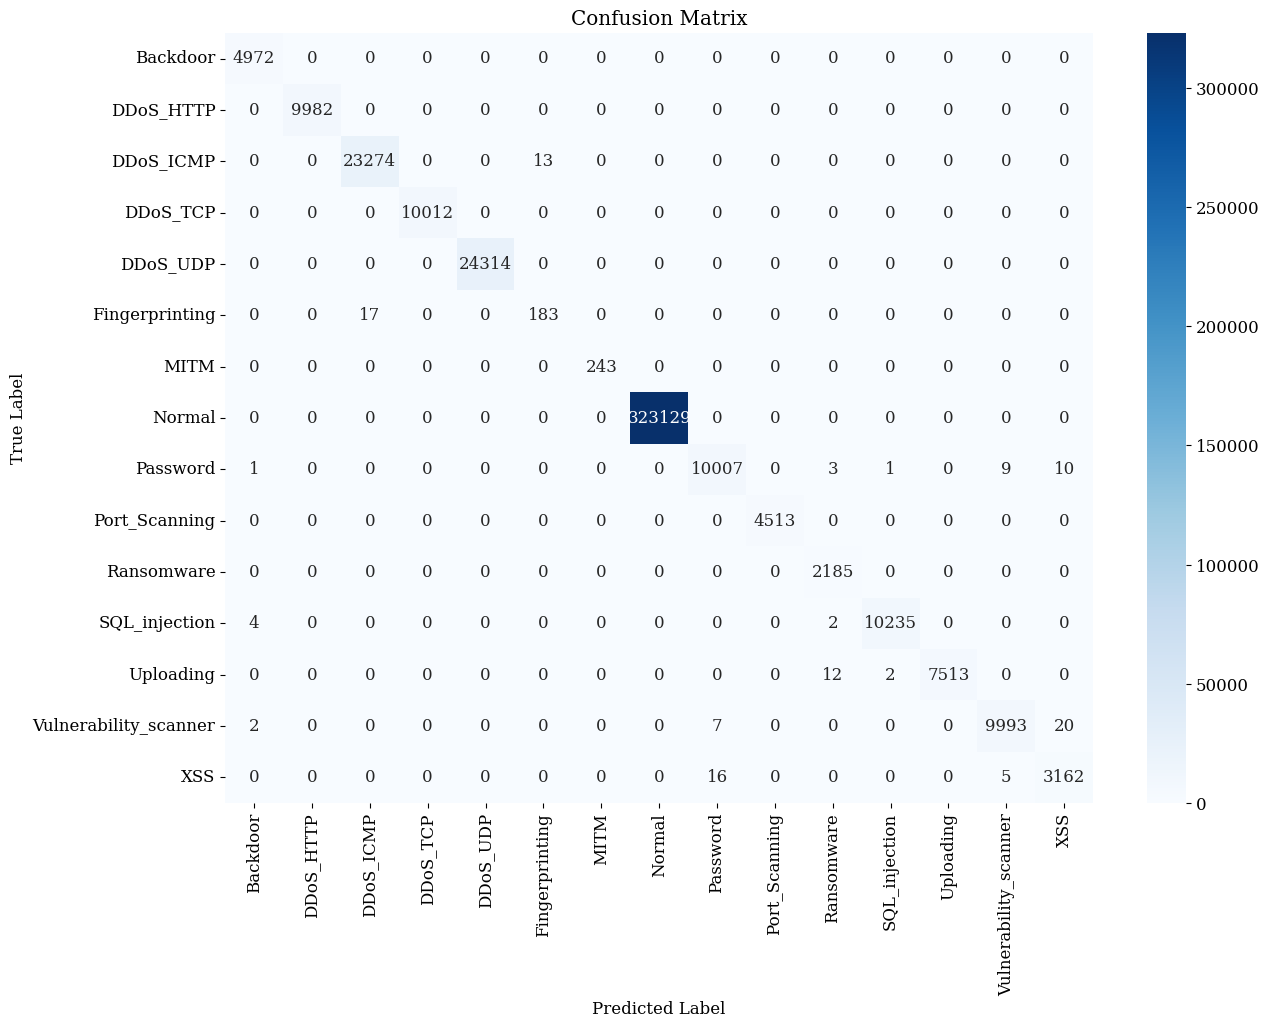

In [ ]:
# === Step 3: AUC Score ===
# NOTE: For multi-class, use "ovr" (one-vs-rest) strategy
auc_score = roc_auc_score(y_test, y_pred_probs, multi_class="ovr")
print(f"Overall AUC Score (OvR): {auc_score:.4f}")

# === Step 5: Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


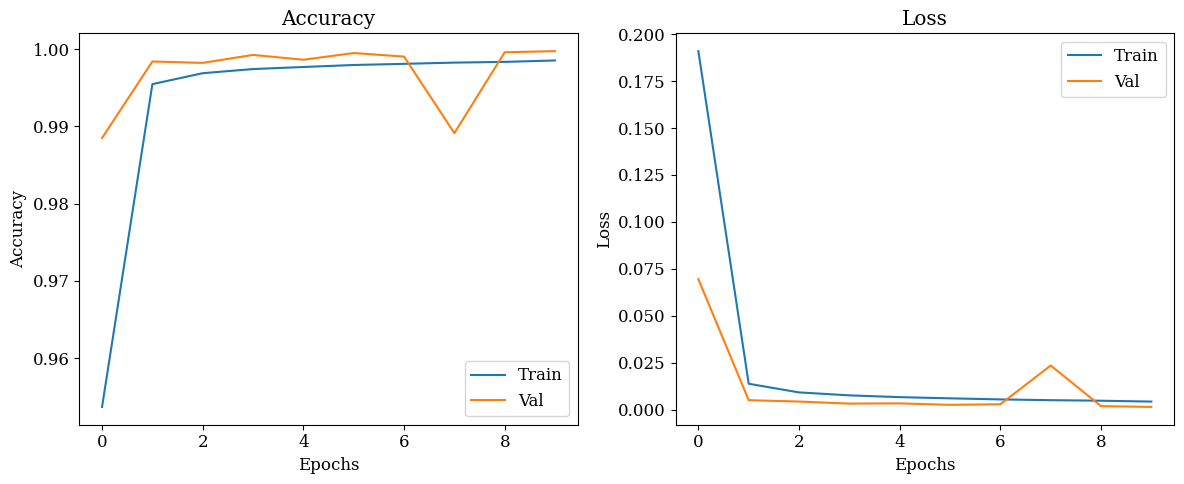

13871/13871 ━━━━━━━━━━━━━━━━━━━━ 490s 35ms/step
13871/13871 ━━━━━━━━━━━━━━━━━━━━ 494s 36ms/step - accuracy: 0.9997 - loss: 0.0014

✅ Test Accuracy: 0.9997

📊 Classification Report:

                       precision    recall  f1-score   support

             Backdoor       1.00      1.00      1.00      4972
            DDoS_HTTP       1.00      1.00      1.00      9982
            DDoS_ICMP       1.00      1.00      1.00     23287
             DDoS_TCP       1.00      1.00      1.00     10012
             DDoS_UDP       1.00      1.00      1.00     24314
       Fingerprinting       0.93      0.92      0.92       200
                 MITM       1.00      1.00      1.00       243
               Normal       1.00      1.00      1.00    323129
             Password       1.00      1.00      1.00     10031
        Port_Scanning       1.00      1.00      1.00      4513
           Ransomware       0.99      1.00      1.00      2185
        SQL_injection       1.00      1.00      1.00     1024

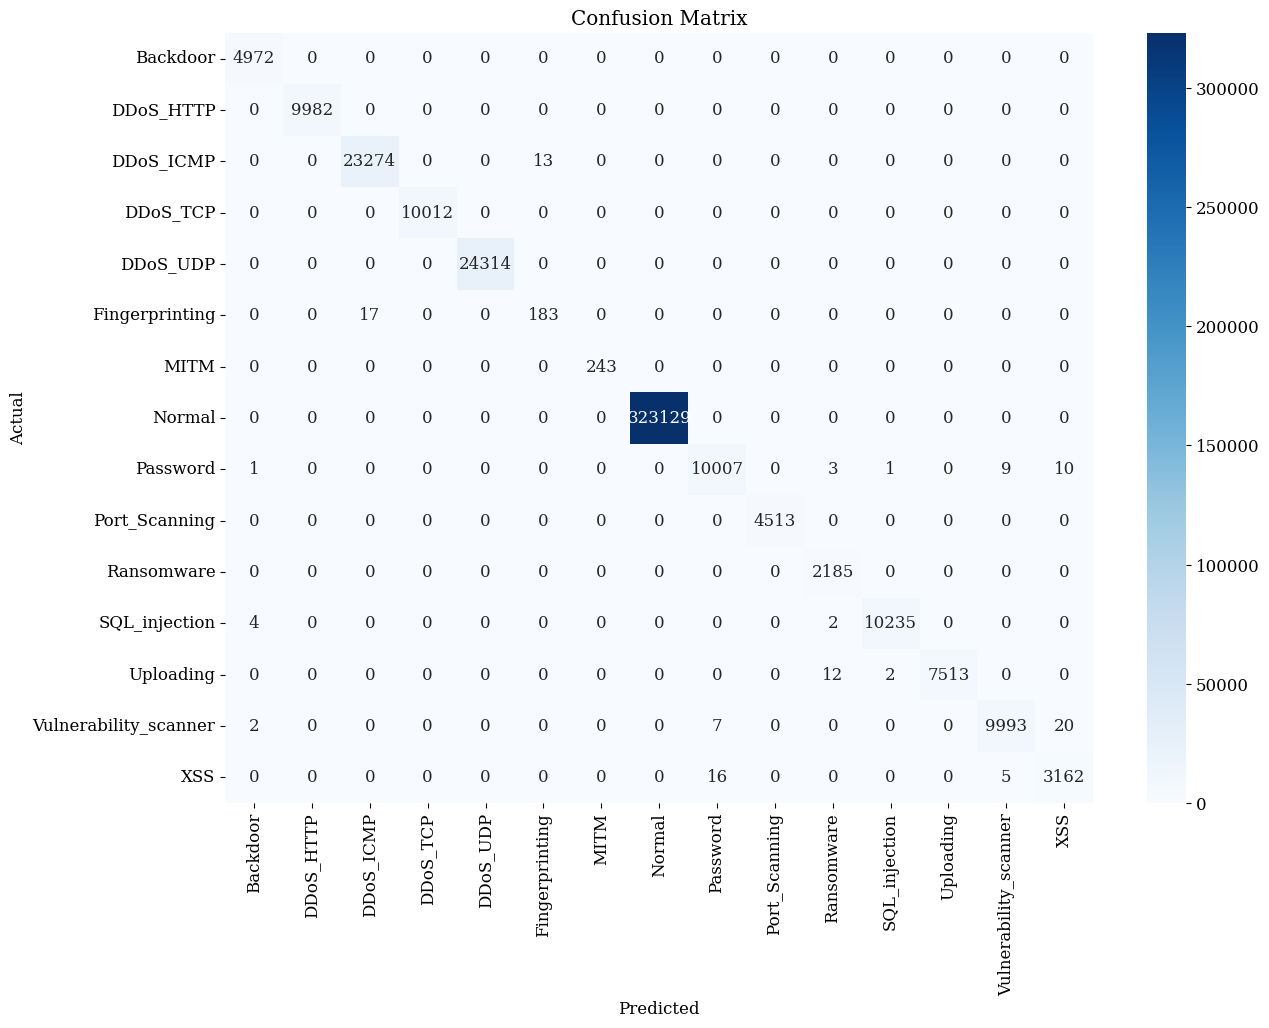

In [ ]:
# ===  STEP 5: Plot Training History ===
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# === STEP 6: Evaluation ===
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict and evaluate
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"\n Test Accuracy: {test_acc:.4f}")

# Classification report
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Thank You**